In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [ ]:
stock_symbol = "AAPL"
data = yf.download(stock_symbol, start="2015-01-01", end="2024-01-01")
close_prices = data["Close"].values.reshape(-1, 1)

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
close_prices_scaled = scaler.fit_transform(close_prices)

In [ ]:
def create_sequences(data, seq_length=60):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

In [ ]:
seq_length = 60
X, y = create_sequences(close_prices_scaled, seq_length)

In [ ]:
split_ratio = 0.8
split_idx = int(len(X) * split_ratio)
X_train, y_train = X[:split_idx], y[:split_idx]
X_test, y_test = X[split_idx:], y[split_idx:]

In [ ]:
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(seq_length, 1)),
    LSTM(50, return_sequences=False),
    Dense(25, activation="relu"),
    Dense(1)
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Compile the model
model.compile(optimizer="adam", loss="mean_squared_error")

# Train the model
model.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_test, y_test))

# Make predictions
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)  # Convert back to original scale

Epoch 1/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 61ms/step - loss: 0.0348 - val_loss: 0.0033
Epoch 2/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - loss: 4.5269e-04 - val_loss: 0.0017
Epoch 3/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - loss: 4.1676e-04 - val_loss: 0.0016
Epoch 4/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 3.8347e-04 - val_loss: 0.0016
Epoch 5/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 3.9529e-04 - val_loss: 0.0019
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step


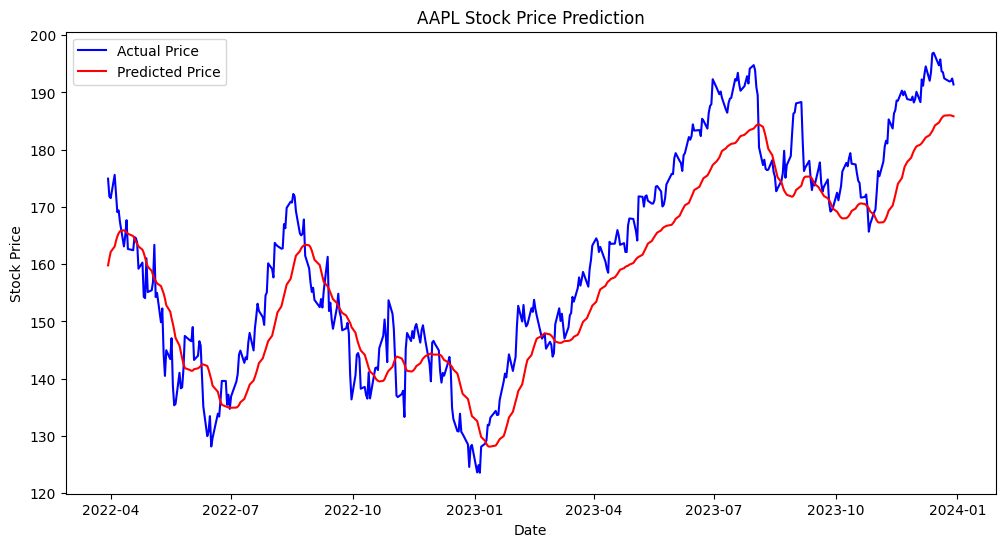

In [ ]:
# Plot actual vs predicted prices
plt.figure(figsize=(12,6))
plt.plot(data.index[-len(y_test):], scaler.inverse_transform(y_test.reshape(-1, 1)), label="Actual Price", color="blue")
plt.plot(data.index[-len(y_test):], predictions, label="Predicted Price", color="red")
plt.legend()
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.title(f"{stock_symbol} Stock Price Prediction")
plt.show()